In [36]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from ripplegw.waveforms import IMRPhenomD
import matplotlib.pyplot as plt
from ripplegw import ms_to_Mc_eta, lambdas_to_lambda_tildes
from ripplegw.constants import MSUN, gt
from ripplegw.waveforms.TaylorF2QM_utils import get_quadparam_octparam, f_contact, f_ISCO, f_merger, f_RLO, f_contact_ECO
from jax import grad, vmap
from functools import partial

from ripplegw.waveforms import TaylorF2QM
from ripplegw.waveforms import TaylorF2QM_taper
from ripplegw.waveforms import TaylorF2

import lalsimulation as lalsim
import lal

from ripplegw import get_eff_pads

params = {"axes.grid": True,
        "text.usetex" : True,
        "font.family" : "serif",
        "ytick.color" : "black",
        "axes.labelcolor" : "black",
        "axes.edgecolor" : "black",
        "font.serif" : ["Computer Modern Serif"],
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "axes.labelsize": 16,
        "legend.fontsize": 16,
        "legend.title_fontsize": 16,
        "figure.titlesize": 16}

plt.rcParams.update(params)

jax.config.update("jax_enable_x64", True) # improve precision for comparing waveforms

Set the parameters

In [37]:
m1 = 1.2
m2 = 0.4

C1 = 0.1
C2 = C1

chi1 = 0.
chi2 = 0.

lambda1 = 0
lambda2 = 500

distance = 440.

In [38]:
# Frequency grid
T = 16
f_l = 20.0
# f_sampling = 2 * 512
f_sampling = 2 * 4096
f_u = f_sampling // 2
f_ref = f_l

delta_t = 1 / f_sampling
tlen = int(round(T / delta_t))
freqs = np.fft.rfftfreq(tlen, delta_t)
df = freqs[1] - freqs[0]
fs = freqs[(freqs > f_l) & (freqs < f_u)]

In [39]:
m1_msun = m1
m2_msun = m2
chi1 = chi1
chi2 = chi2
tc = 0
phic = 0
dist_mpc = distance
inclination = np.pi / 2

# Convert from source values to sample values
Mc, eta = ms_to_Mc_eta(jnp.array([m1_msun, m2_msun]))
lambda_tilde, delta_lambda_tilde = lambdas_to_lambda_tildes(jnp.array([lambda1, lambda2, m1, m2]))

#Two parameter lists: one without and one with compactness as a parameter
theta_ripple = jnp.array([Mc, eta, chi1, chi2, lambda_tilde, delta_lambda_tilde, dist_mpc, tc, phic, inclination])
theta_ripple_C = jnp.array([Mc, eta, chi1, chi2, lambda_tilde, delta_lambda_tilde, C1, C2, dist_mpc, tc, phic, inclination])

fs_ripple = jnp.arange(f_l, f_u, df)[1:]

# And finally lets generate the waveform!
hp_ripple, hc_ripple = TaylorF2QM.gen_TaylorF2QM_hphc(fs_ripple, theta_ripple, f_ref, stop="contact ECO")
hp_ripple_C, hc_ripple_C = TaylorF2QM.gen_TaylorF2QM_hphc(fs_ripple, theta_ripple_C, f_ref, stop="contact ECO")

No compactness given, defaulting to ISCO


Compare the waveforms

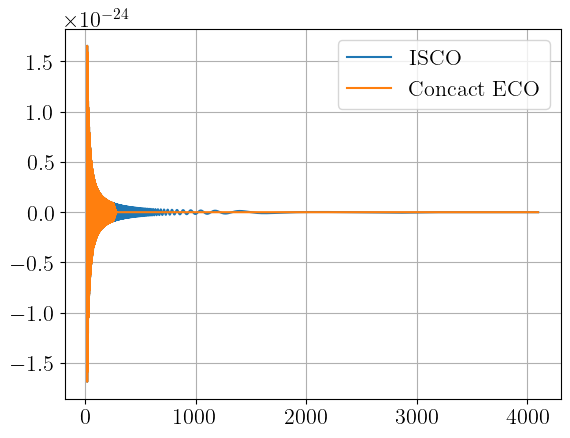

In [40]:
plt.plot(fs_ripple, hp_ripple.real, label="ISCO")
plt.plot(fs_ripple, hp_ripple_C.real, label = "Concact ECO")
plt.legend()
plt.show()

Check the tapering

Merger frequency ISCO:  2748.234181931515
Merger frequency contact ECO:  245.80953795549573


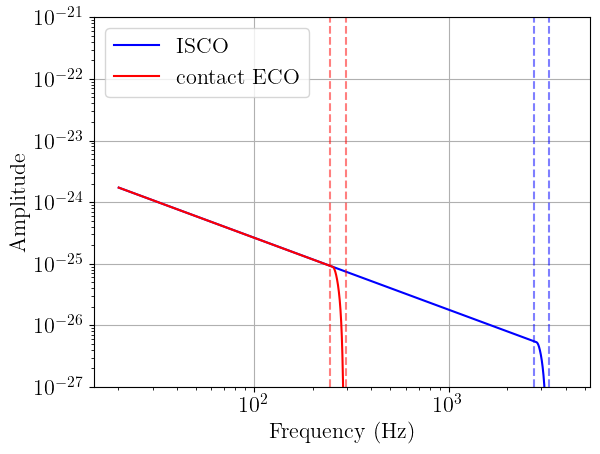

In [41]:
A_ripple = jnp.abs(hp_ripple)
A_ripple_C = jnp.abs(hp_ripple_C)

f_merger_ISCO = f_ISCO(m1, m2)
f_merger_ISCO = float(f_merger_ISCO)
print("Merger frequency ISCO: ", f_merger_ISCO)

f_merger_contact_ECO = f_contact_ECO(m1, m2, C1, C2)
f_merger_contact_ECO = float(f_merger_contact_ECO)
print("Merger frequency contact ECO: ", f_merger_contact_ECO)

# Choose whether we plot the angle or the phase
plot_angle = True

# Plot the amplitude
plt.plot(fs_ripple, A_ripple, label = "ISCO", color="blue")
plt.plot(fs_ripple, A_ripple_C, label = "contact ECO", color="red")

#plt.title(r"Amplitudes $h_+$ ($m_1, m_2) = ({}, {}$) ($\chi_1, \chi_2) = ({}, {}$) ($\Lambda_1, \Lambda_2) = ({}, {}$)".format(m1, m2, chi1, chi2, lambda1, lambda2))
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.ylim(1e-27, 1e-21)
plt.xlim(f_l - 5)
plt.legend()

# Plot where the Planck taper has to take place
plt.axvline(f_merger_ISCO, linestyle = "--", color = 'blue', label = 'Planck taper', alpha=0.5)
plt.axvline(1.2 * f_merger_ISCO, linestyle = "--", color = 'blue', alpha=0.5)

plt.axvline(f_merger_contact_ECO, linestyle = "--", color = 'red', label = 'Planck taper ECO', alpha=0.5)
plt.axvline(1.2 * f_merger_contact_ECO, linestyle = "--", color = 'red', alpha=0.5)

plt.show()

## Switch to TaylorF2QM_taper

If TaylorF2_taper is implemented properly, the plots below should be identical to the plots above

In [42]:
m1_msun = m1
m2_msun = m2
chi1 = chi1
chi2 = chi2
tc = 0
phic = 0
dist_mpc = distance
inclination = np.pi / 2

f_merger_contact_ECO = f_contact_ECO(m1, m2, C1, C2)
f_merger_contact_ECO = float(f_merger_contact_ECO)
print("Merger frequency contact ECO: ", f_merger_contact_ECO)

f_merger_ISCO = f_ISCO(m1, m2)
f_merger_ISCO = float(f_merger_ISCO)
print("Merger frequency ISCO: ", f_merger_ISCO)

# Convert from source values to sample values
Mc, eta = ms_to_Mc_eta(jnp.array([m1_msun, m2_msun]))
lambda_tilde, delta_lambda_tilde = lambdas_to_lambda_tildes(jnp.array([lambda1, lambda2, m1, m2]))

#Two parameter lists: one without and one with compactness as a parameter
theta_ripple = jnp.array([Mc, eta, chi1, chi2, lambda_tilde, delta_lambda_tilde, f_merger_ISCO, dist_mpc, tc, phic, inclination])
theta_ripple_C = jnp.array([Mc, eta, chi1, chi2, lambda_tilde, delta_lambda_tilde, f_merger_contact_ECO, dist_mpc, tc, phic, inclination])

fs_ripple = jnp.arange(f_l, f_u, df)[1:]

# Call TaylorF2QM_taper instead of TaylorF2QM
hp_ripple, hc_ripple = TaylorF2QM_taper.gen_TaylorF2QM_hphc(fs_ripple, theta_ripple, f_ref, stop="contact ECO")
hp_ripple_C, hc_ripple_C = TaylorF2QM_taper.gen_TaylorF2QM_hphc(fs_ripple, theta_ripple_C, f_ref, stop="contact ECO")

Merger frequency contact ECO:  245.80953795549573
Merger frequency ISCO:  2748.234181931515


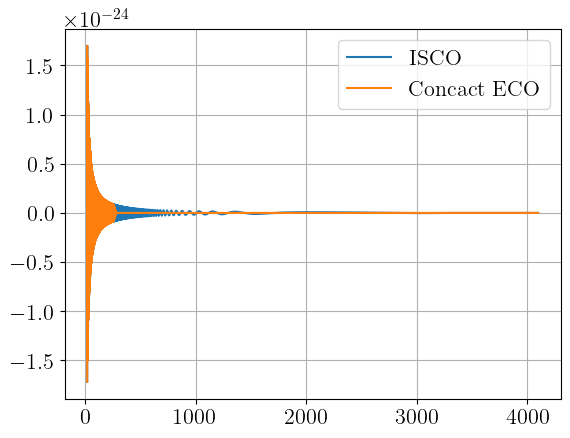

In [43]:
plt.plot(fs_ripple, hp_ripple.real, label="ISCO")
plt.plot(fs_ripple, hp_ripple_C.real, label = "Concact ECO")
plt.legend()
plt.show()

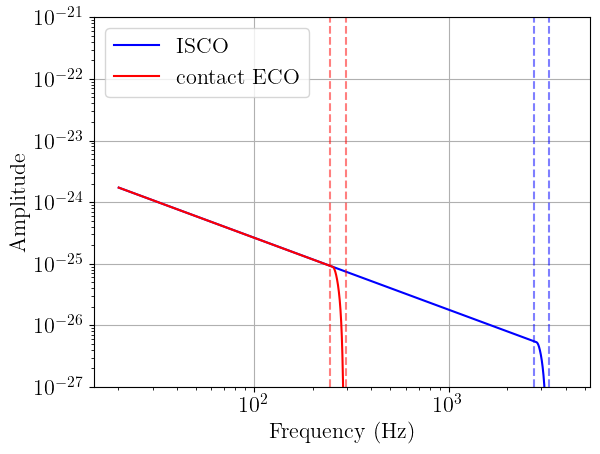

In [44]:
A_ripple = jnp.abs(hp_ripple)
A_ripple_C = jnp.abs(hp_ripple_C)

# Choose whether we plot the angle or the phase
plot_angle = True

# Plot the amplitude
plt.plot(fs_ripple, A_ripple, label = "ISCO", color="blue")
plt.plot(fs_ripple, A_ripple_C, label = "contact ECO", color="red")

#plt.title(r"Amplitudes $h_+$ ($m_1, m_2) = ({}, {}$) ($\chi_1, \chi_2) = ({}, {}$) ($\Lambda_1, \Lambda_2) = ({}, {}$)".format(m1, m2, chi1, chi2, lambda1, lambda2))
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.ylim(1e-27, 1e-21)
plt.xlim(f_l - 5)
plt.legend()

# Plot where the Planck taper has to take place
plt.axvline(f_merger_ISCO, linestyle = "--", color = 'blue', label = 'Planck taper', alpha=0.5)
plt.axvline(1.2 * f_merger_ISCO, linestyle = "--", color = 'blue', alpha=0.5)

plt.axvline(f_merger_contact_ECO, linestyle = "--", color = 'red', label = 'Planck taper ECO', alpha=0.5)
plt.axvline(1.2 * f_merger_contact_ECO, linestyle = "--", color = 'red', alpha=0.5)

plt.show()